## Dataset Exploration

In [1]:
from pathlib import Path

data_root = Path("..") / "dataset" / "raw"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}

dataset_info = {}

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
    class_counts = {}

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        image_count = sum(
            1
            for file_path in class_dir.rglob("*")
            if file_path.is_file()
            and file_path.suffix.lower() in image_extensions
        )

        class_counts[class_dir.name] = image_count

    dataset_info[split_dir.name] = class_counts

    print(f"\n{split_dir.name}:")
    print(f"Classes ({len(class_counts)}): {list(class_counts.keys())}")

    for class_name, image_count in class_counts.items():
        print(f"  {class_name}: {image_count} images")

    print(f"Total images: {sum(class_counts.values())}")


test:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 50 images
  autobus: 50 images
  kamyun: 50 images
  kamyunet: 50 images
  minibus: 50 images
  savari: 50 images
  taxi: 50 images
  vanet: 50 images
Total images: 400

train:
Classes (8): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
  ambulance: 50 images
  autobus: 50 images
  kamyun: 50 images
  kamyunet: 50 images
  minibus: 50 images
  savari: 50 images
  taxi: 50 images
  vanet: 50 images
Total images: 400

unclean:
Classes (9): ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'neysan', 'savari', 'taxi', 'vanet']
  ambulance: 50 images
  autobus: 50 images
  kamyun: 50 images
  kamyunet: 50 images
  minibus: 50 images
  neysan: 50 images
  savari: 50 images
  taxi: 50 images
  vanet: 50 images
Total images: 450


In [2]:
from pathlib import Path

import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Locate the raw dataset
# ---------------------------------------------------------

data_root = Path("..") / "dataset" / "raw"

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".gif", ".tif", ".tiff", ".webp"
}


# ---------------------------------------------------------
# 2. Inspect every image in every class of every split
# ---------------------------------------------------------

records = []

for split_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):

    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):

        for file_path in sorted(class_dir.rglob("*")):

            # Ignore files that are not recognized as images
            if not file_path.is_file():
                continue

            if file_path.suffix.lower() not in image_extensions:
                continue

            # Default values in case the image cannot be read
            width = None
            height = None
            dpi_x = None
            dpi_y = None
            image_format = None
            mode = None
            readable = False
            aspect_ratio = None
            error = None

            try:
                # Open the image
                with Image.open(file_path) as img:

                    # Basic image information
                    width, height = img.size
                    image_format = img.format
                    mode = img.mode

                    # DPI information
                    dpi = img.info.get("dpi")

                    if dpi is not None:
                        dpi_x, dpi_y = dpi

                    # Aspect ratio
                    if height != 0:
                        aspect_ratio = width / height

                    # Verify that the image data can actually be read
                    img.verify()

                    readable = True

            except Exception as e:
                error = str(e)

            # Store everything in one record
            records.append({
                "split": split_dir.name,
                "class": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path),
                "width": width,
                "height": height,
                "dpi_x": dpi_x,
                "dpi_y": dpi_y,
                "format": image_format,
                "mode": mode,
                "readable": readable,
                "aspect_ratio": aspect_ratio,
                "error": error,
            })


# ---------------------------------------------------------
# 3. Create one master DataFrame
# ---------------------------------------------------------

image_metadata = pd.DataFrame(records)


# ---------------------------------------------------------
# 4. Display basic information
# ---------------------------------------------------------

print(f"Total images inspected: {len(image_metadata)}")

print(
    f"Unreadable images: "
    f"{(~image_metadata['readable']).sum()}"
)

Total images inspected: 1250
Unreadable images: 0


In [3]:
for split_name in sorted(image_metadata["split"].unique()):

    print("=" * 100)
    print(f" SPLIT: {split_name}")
    print("=" * 100)

    split_data = image_metadata[
        image_metadata["split"] == split_name
    ]

    for class_name in sorted(split_data["class"].unique()):

        print(f"\n--- CLASS: {class_name} ---")

        class_data = split_data[
            split_data["class"] == class_name
        ].copy()

        # display(
        #     class_data[
        #         [
        #             "filename",
        #             "width",
        #             "height",
        #             "dpi_x",
        #             "dpi_y",
        #             "format",
        #             "mode",
        #             "readable",
        #             "aspect_ratio",
        #             "error",
        #         ]
        #     ]
        # )

 SPLIT: test

--- CLASS: ambulance ---

--- CLASS: autobus ---

--- CLASS: kamyun ---

--- CLASS: kamyunet ---

--- CLASS: minibus ---

--- CLASS: savari ---

--- CLASS: taxi ---

--- CLASS: vanet ---
 SPLIT: train

--- CLASS: ambulance ---

--- CLASS: autobus ---

--- CLASS: kamyun ---

--- CLASS: kamyunet ---

--- CLASS: minibus ---

--- CLASS: savari ---

--- CLASS: taxi ---

--- CLASS: vanet ---
 SPLIT: unclean

--- CLASS: ambulance ---

--- CLASS: autobus ---

--- CLASS: kamyun ---

--- CLASS: kamyunet ---

--- CLASS: minibus ---

--- CLASS: neysan ---

--- CLASS: savari ---

--- CLASS: taxi ---

--- CLASS: vanet ---


Hashed images: 1250  |  Failed to hash: 0
Compared 780625 pairs  |  listed: similarity >= 0.90 (Hamming distance <= 25 of 256)  |  similar pairs found: 24
Clusters (size: count) -> 2 images: 24
Rows needing manual review: 1
--- all similar pairs ---


similarity,cluster_num,same_class,class_a,class_b,same_split,split_a,split_b,filename_a,path_a,filename_b,path_b,auto_decision
1.000,2,True,ambulance,ambulance,False,test,unclean,200396165.jpg,..\dataset\raw\test\ambulance\200396165.jpg,200396165.jpg,..\dataset\raw\unclean\ambulance\200396165.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,test,unclean,214830125.jpg,..\dataset\raw\test\ambulance\214830125.jpg,214830125.jpg,..\dataset\raw\unclean\ambulance\214830125.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,test,unclean,215713763.jpg,..\dataset\raw\test\ambulance\215713763.jpg,215713763.jpg,..\dataset\raw\unclean\ambulance\215713763.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,test,unclean,216095686.jpg,..\dataset\raw\test\ambulance\216095686.jpg,216095686.jpg,..\dataset\raw\unclean\ambulance\216095686.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,test,unclean,217040489.jpg,..\dataset\raw\test\ambulance\217040489.jpg,217040489.jpg,..\dataset\raw\unclean\ambulance\217040489.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,test,unclean,218089422.jpg,..\dataset\raw\test\ambulance\218089422.jpg,218089422.jpg,..\dataset\raw\unclean\ambulance\218089422.jpg,"keep A, exclude B"
1.000,2,True,minibus,minibus,False,test,unclean,218138154.jpg,..\dataset\raw\test\minibus\218138154.jpg,218138154.jpg,..\dataset\raw\unclean\minibus\218138154.jpg,"keep A, exclude B"
1.000,2,True,minibus,minibus,False,test,unclean,218307381.jpg,..\dataset\raw\test\minibus\218307381.jpg,218307381.jpg,..\dataset\raw\unclean\minibus\218307381.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,train,unclean,199984667.jpg,..\dataset\raw\train\ambulance\199984667.jpg,199984667.jpg,..\dataset\raw\unclean\ambulance\199984667.jpg,"keep A, exclude B"
1.000,2,True,ambulance,ambulance,False,train,unclean,206808986.jpg,..\dataset\raw\train\ambulance\206808986.jpg,206808986.jpg,..\dataset\raw\unclean\ambulance\206808986.jpg,"keep A, exclude B"

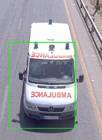
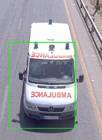
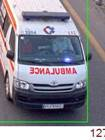
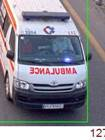
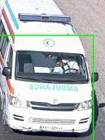
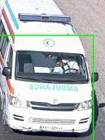
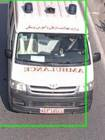
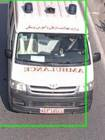
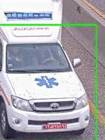
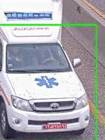
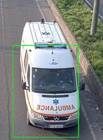
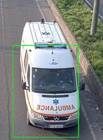
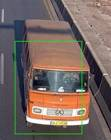
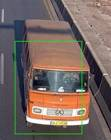
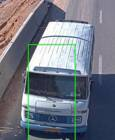
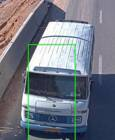
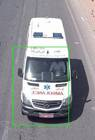
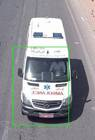
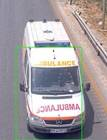
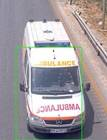
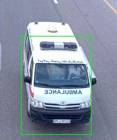
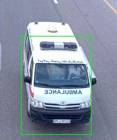
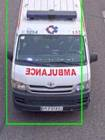
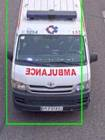
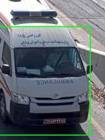
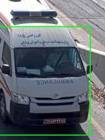
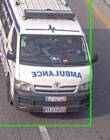
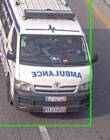
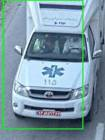
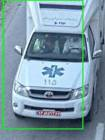
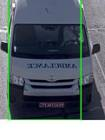
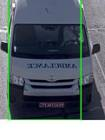
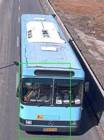
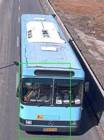
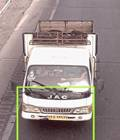
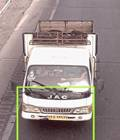
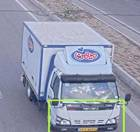
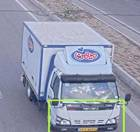
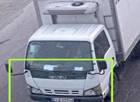
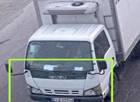
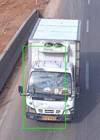
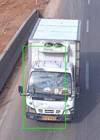
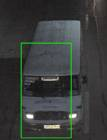
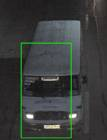
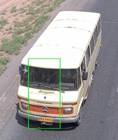
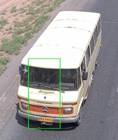
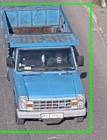
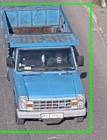

Saved 24 rows to D:\BootCamp Sharif AI\Project 2 - Vehicle Classifier with traffic images\data\duplicate_pairs_report.csv
Saved 23 automatic exclusions to D:\BootCamp Sharif AI\Project 2 - Vehicle Classifier with traffic images\data\label_corrections_auto_duplicates.csv


{'hash_method': 'phash',
 'hash_size': 16,
 'similarity': 0.6797,
 'hamming_distance': 82,
 'n_bits': 256}

In [8]:
from IPython.display import HTML, display
from vehicle_classifier import duplicate_detection as dd

THRESHOLD = 0.9

hashed = dd.compute_phashes(image_metadata)
report = dd.build_duplicate_report(hashed, similarity_threshold=THRESHOLD)

print('='*20)
print('--- all similar pairs ---')
display(HTML(dd.table_to_html(report)))

dd.save_duplicate_report(report)
dd.save_label_corrections(report)

dd.compare_images(
    r"dataset\raw\train\autobus\216664450.jpg",
    r"dataset\raw\train\autobus\216802875.jpg",
    hash_method="phash",   # "ahash" | "phash" | "dhash" | "whash"
)